In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
complaints = pd.read_csv("../data/processed/complaints_sample.csv")

customers = pd.read_csv("../data/raw/bank_customers.csv")

survey = pd.read_csv("../data/raw/customer_survey.csv")

In [4]:
complaints.head()

,product,issue,complaint_text,company,state,date_received
0,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Subject : Complaint Against PNC Bank for Unres...,PNC Bank N.A.,MD,2024-11-25
1,Credit reporting or other personal consumer re...,Incorrect information on your report,XXXX contact XXXX bank to verify an account th...,"EQUIFAX, INC.",LA,2023-11-21
2,"Money transfer, virtual currency, or money ser...",Unauthorized transactions or other transaction...,Im a trader of Bitcoin on the platform XXXX. I...,"Paypal Holdings, Inc",GA,2022-08-24
3,Checking or savings account,Managing an account,I deposited a check to XXXX XXXX because the c...,UNITED SERVICES AUTOMOBILE ASSOCIATION,NY,2021-11-11
4,"Money transfer, virtual currency, or money ser...",Other transaction problem,I am filing a complaint against cash app ( Blo...,"Block, Inc.",MO,2025-02-24


In [5]:
customers.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
survey.head()

,customer_id,nps_score,customer_effort_score,satisfaction_score,interaction_channel,complaint_flag
0,1,6,3,3,web,0
1,2,3,5,5,mobile_app,1
2,3,10,1,4,call_center,0
3,4,7,1,3,branch,0
4,5,4,1,2,mobile_app,0


In [7]:
customers.info()
survey.info()
complaints.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    

In [8]:
customers.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
survey.isna().sum()

customer_id              0
nps_score                0
customer_effort_score    0
satisfaction_score       0
interaction_channel      0
complaint_flag           0
dtype: int64

In [10]:
complaints.isna().sum()

product            0
issue              0
complaint_text     0
company            0
state             79
date_received      0
dtype: int64

In [11]:
customers["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

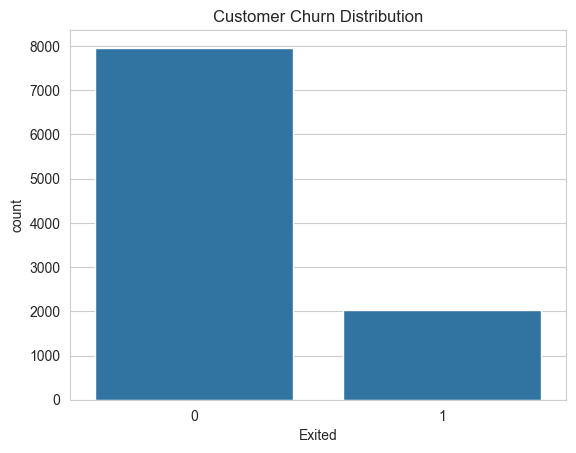

In [12]:
sns.countplot(x="Exited", data=customers)

plt.title("Customer Churn Distribution")

plt.show()

The dataset shows an imbalanced distribution between churned and retained customers. 
Understanding the drivers behind churn will be essential to improve customer retention strategies.

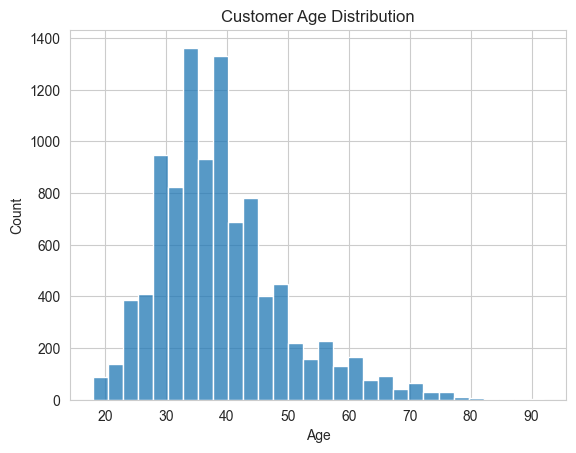

In [13]:
plt.figure()

sns.histplot(customers["Age"], bins=30)

plt.title("Customer Age Distribution")

plt.show()

Understanding customer demographics may help identify segments more likely to churn.

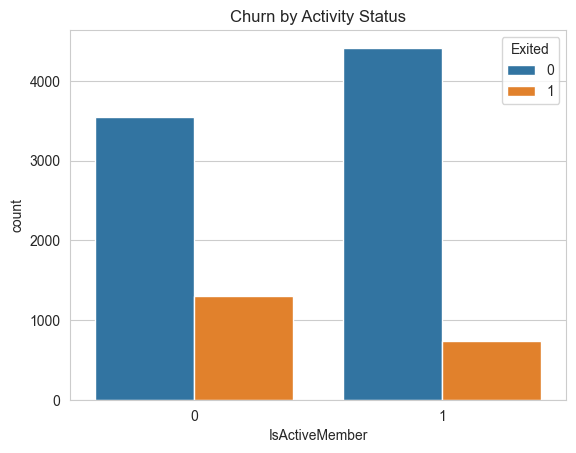

In [14]:
sns.countplot(x="IsActiveMember", hue="Exited", data=customers)

plt.title("Churn by Activity Status")

plt.show()

Inactive customers appear to churn significantly more often than active ones.
This suggests engagement is a key factor in customer retention.

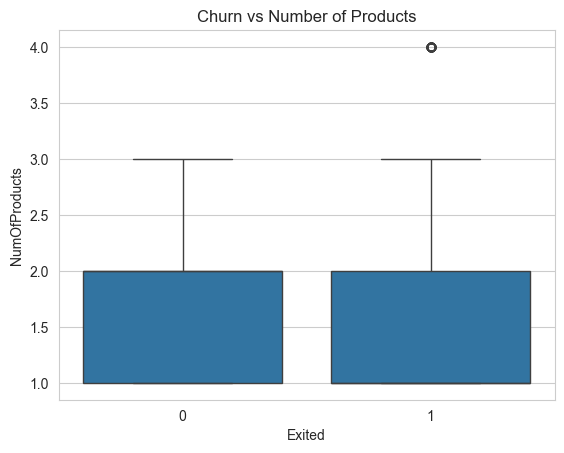

In [15]:
sns.boxplot(x="Exited", y="NumOfProducts", data=customers)

plt.title("Churn vs Number of Products")

plt.show()

Customers with fewer products appear more likely to churn.
Cross-selling additional services may reduce churn risk.

In [ ]:
def categorize_nps(score):

    if score >= 9:
        return "Promoter"
    
    elif score >= 7:
        return "Passive"
    
    else:
        return "Detractor"

survey["nps_category"] = survey["nps_score"].apply(categorize_nps)

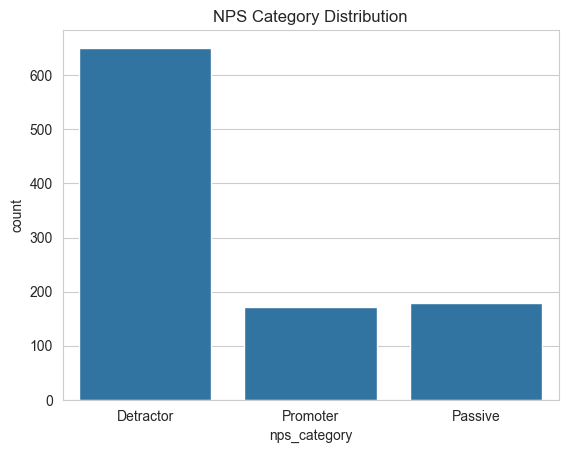

In [17]:
sns.countplot(x="nps_category", data=survey)

plt.title("NPS Category Distribution")

plt.show()

NPS categories allow us to segment customers between promoters, passives and detractors.
Detractors are expected to show higher churn risk.

In [18]:
complaints["complaint_text"].head()

0    Subject : Complaint Against PNC Bank for Unres...
1    XXXX contact XXXX bank to verify an account th...
2    Im a trader of Bitcoin on the platform XXXX. I...
3    I deposited a check to XXXX XXXX because the c...
4    I am filing a complaint against cash app ( Blo...
Name: complaint_text, dtype: str

In [19]:
complaints["complaint_text"].str.len().describe()

count    20000.000000
mean      1014.385350
std       1302.025694
min          4.000000
25%        348.000000
50%        663.000000
75%       1200.250000
max      32545.000000
Name: complaint_text, dtype: float64

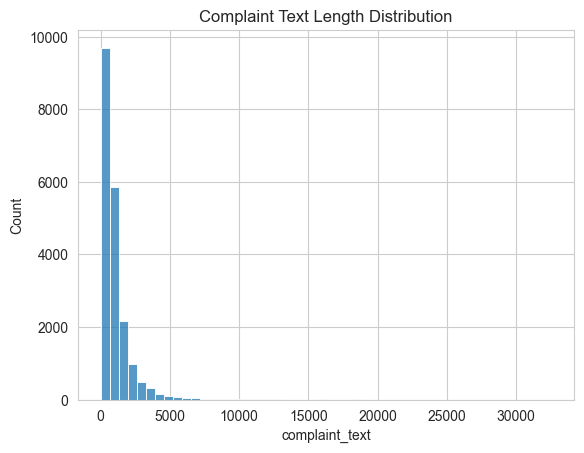

In [20]:
sns.histplot(complaints["complaint_text"].str.len(), bins=50)

plt.title("Complaint Text Length Distribution")

plt.show()

Customer complaints contain rich textual information that can be analyzed using NLP techniques 
to identify dissatisfaction drivers and recurring issues.

In [21]:
complaints["product"].value_counts().head(10)

product
Credit reporting or other personal consumer reports                             8988
Credit reporting, credit repair services, or other personal consumer reports    4419
Debt collection                                                                 2130
Checking or savings account                                                      815
Mortgage                                                                         752
Money transfer, virtual currency, or money service                               602
Credit card                                                                      586
Credit card or prepaid card                                                      570
Student loan                                                                     317
Vehicle loan or lease                                                            249
Name: count, dtype: int64

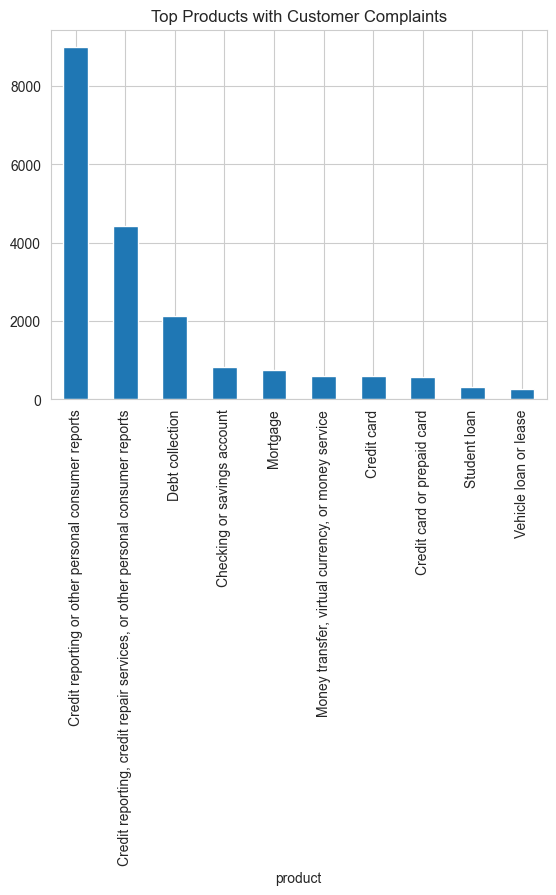

In [22]:
complaints["product"].value_counts().head(10).plot(kind="bar")

plt.title("Top Products with Customer Complaints")

plt.show()

Certain products generate significantly more complaints, which may indicate operational issues or friction in customer journeys.

In [23]:
customers.to_csv("../data/processed/customers_clean.csv", index=False)

survey.to_csv("../data/processed/survey_clean.csv", index=False)